In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from q3dfit.q3din import q3din
from q3dfit.q3dutil import get_q3dio

In [2]:
2.294/0.5007 - 1

3.5815857799081288

In [3]:
indir = "input/"
outdir = "output/"
label = "4C1971"

if not os.path.exists(indir):
    os.makedirs(indir)
if not os.path.exists(outdir):
    os.makedirs(outdir)

logfile = os.path.join(indir, label+"-fitlog.txt")
infile = "4C1971_with_data_quality.fits"

# 
q3di = q3din(infile, label, outdir=outdir, logfile=logfile)
q3di.argsreadcube = {"wmapext": True}
cube = q3di.load_cube()
q3di.name = label
q3di.zsys_gas = 3.5892
q3di.fitrange = [2.15, 2.4]

#
lines = ['Hbeta', '[OIII]4959', '[OIII]5007']
q3di.init_linefit(lines, linetie='[OIII]5007', maxncomp=1, checkcomp=False)
q3di.siglim_gas = np.array([40., 2000.])
q3di.spect_convol['ws_instrum'] = {'JWST_NIRSPEC':['G235H']}
# q3di.argslinefit['method'] = 'leastsq'
q3di.argslinefit['method'] = 'least_squares'
q3di.argslinefit['ftol'] = 1.e-8
q3di.argslinefit['gtol'] = 1.e-8
q3di.argslinefit['xtol'] = 1.e-8
q3di.argslinefit['x_scale'] = 'jac'
q3di.argslinefit['tr_solver'] = 'lsmr'
q3di.argscheckcomp['sigcut'] = 3.
q3di.argscheckcomp['ignore']= ['Hbeta']
# for i in lines:
#     # q3di.zinit_gas[i][:,:,2] = 3.585
#     # q3di.zinit_gas[i][:,:,1] = 3.5816
#     # q3di.zinit_gas[i][:,:,0] = 3.5936
#     # q3di.siginit_gas[i][:,:,1] = 200.
#     q3di.siginit_gas[i][:,:,0] = 150.
#     ...

# 
q3di.init_contfit("fitpoly")
q3di.argscontfit.update({"fitord": 1})
q3di.maskwidths_def = 5000
q3di.masksig_secondfit = 5
np.save(os.path.join(indir, "q3di.npy"), q3di)

Cube: No wavelength units in header; using micron
Size of data cube: [ 70 , 83 , 3815 ]
Wavelength range: [ 1.660198 , 3.170542 ]  micron
Input flux units:  MJy/sr
Input wave units:  micron
Output flux units:  erg/s/cm2/micron
Output wave units:  micron
NB: q3dfit uses output units for internal calculations.


In [4]:
# run fit
filename_q3di = "input/q3di.npy"
# cols, rows = 18, 33 
cols, rows = None, None
from q3dfit.q3df import q3dfit
q3dfit(filename_q3di, cols, rows, quiet=False, ncores=22, nocrash=True, onefit=True)

Core 11: # spaxels fit=265
Core 10: # spaxels fit=264
Core 19: # spaxels fit=264
Core 12: # spaxels fit=264
Core 13: # spaxels fit=264
Core 21: # spaxels fit=264
Core 7: # spaxels fit=264Core 5: # spaxels fit=264

Core 22: # spaxels fit=265
Core 14: # spaxels fit=264
Core 9: # spaxels fit=264
Core 20: # spaxels fit=264
Core 4: # spaxels fit=264
Core 8: # spaxels fit=264
Core 3: # spaxels fit=264
Core 2: # spaxels fit=264
Core 1: # spaxels fit=264
Core 17: # spaxels fit=264
Core 6: # spaxels fit=264
Core 16: # spaxels fit=264
Core 18: # spaxels fit=264
Core 15: # spaxels fit=264


In [6]:
from q3dfit.q3dcollect import q3dcollect
q3dcollect(q3di, cols=cols, rows=rows, compsortpar="wave", quiet=True)

Sorting components by wave in the upward direction.
        No data for [1, 1]
        No data for [1, 2]
        No data for [1, 3]
        No data for [1, 4]
        No data for [1, 5]
        No data for [1, 75]
        No data for [1, 76]
        No data for [1, 77]
        No data for [1, 78]
        No data for [1, 79]
        No data for [1, 80]
        No data for [1, 81]
        No data for [1, 82]
        No data for [1, 83]
        No data for [2, 1]
        No data for [2, 2]
        No data for [2, 3]
        No data for [2, 4]
        No data for [2, 5]
        No data for [2, 75]
        No data for [2, 76]
        No data for [2, 77]
        No data for [2, 78]
        No data for [2, 79]
        No data for [2, 80]
        No data for [2, 81]
        No data for [2, 82]
        No data for [2, 83]
        No data for [3, 1]
        No data for [3, 2]
        No data for [3, 3]
        No data for [3, 78]
        No data for [3, 79]
        No data for [3, 80]
        N

In [ ]:
def check_significance():
    ...

True


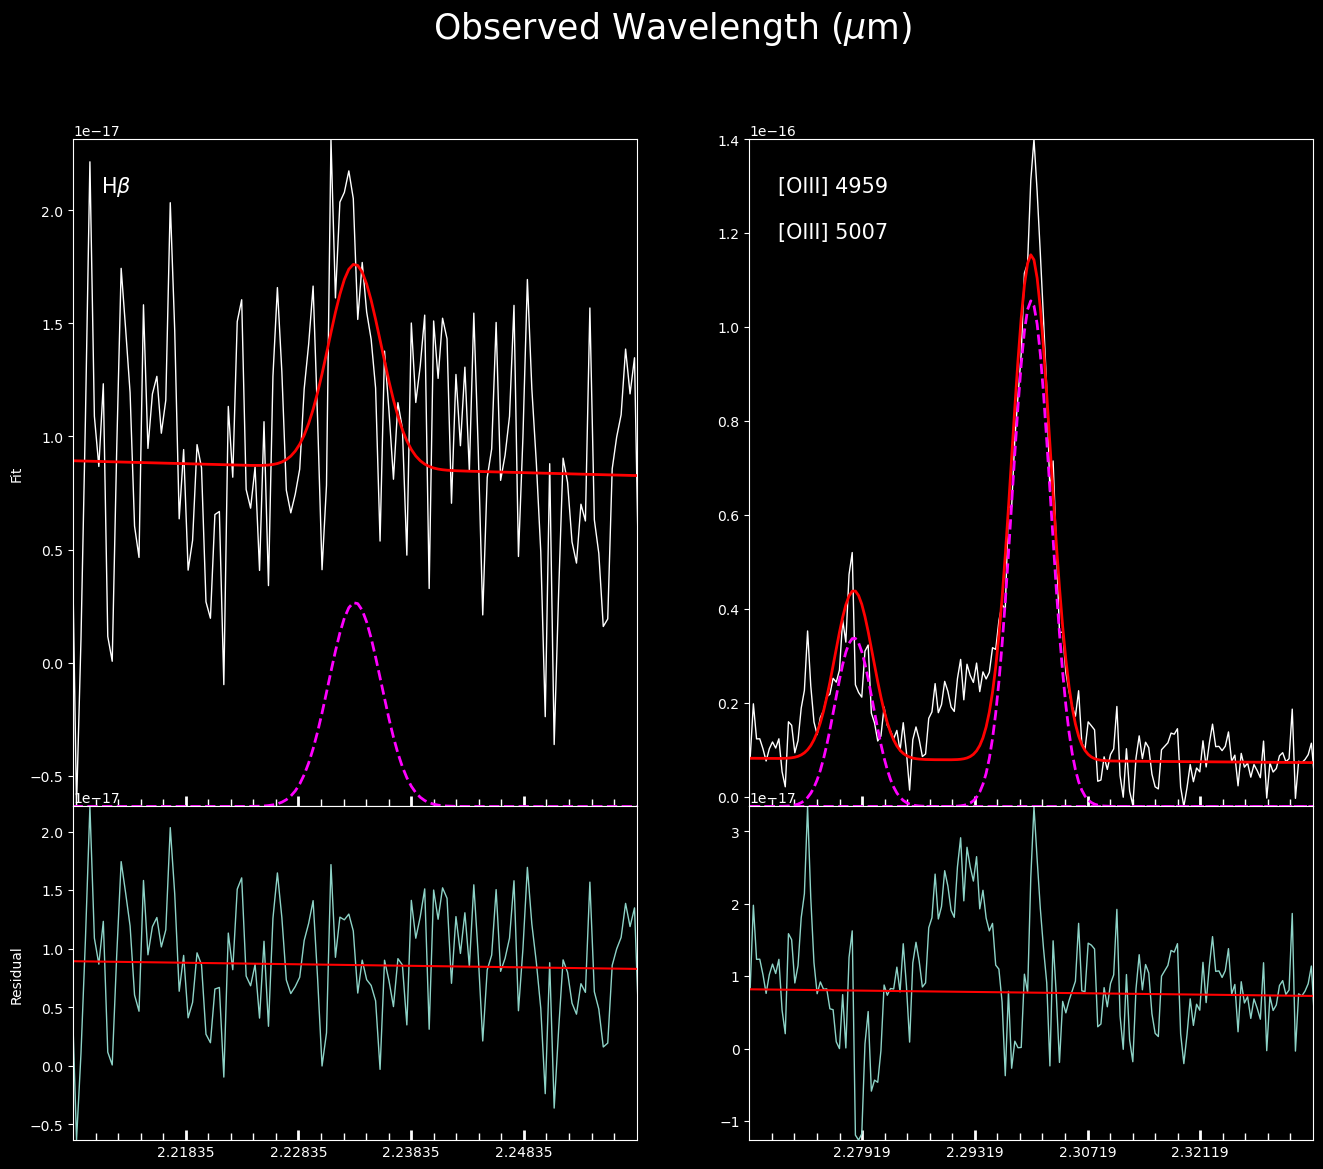

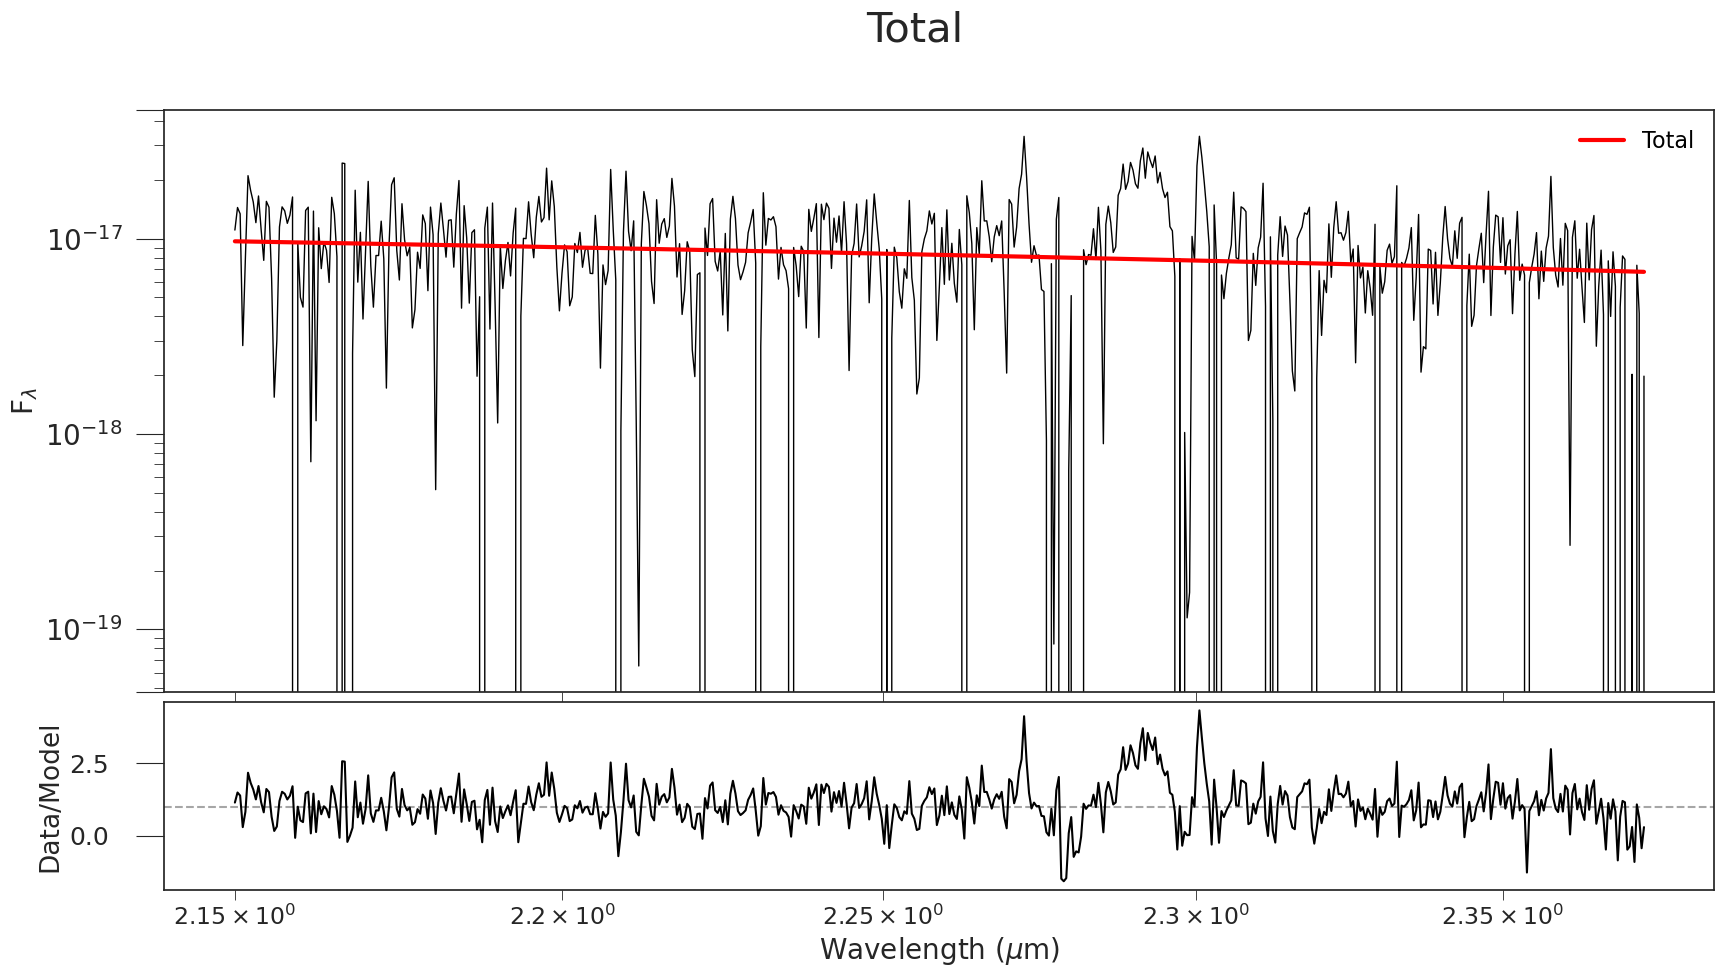

In [ ]:
# # # Open
# q3di = get_q3dio(filename_q3di)
# # print(q3di.__dict__)
# cols, rows = 18, 33 
# from q3dfit.q3dout import load_q3dout 
# q3do = load_q3dout(q3di, cols, rows) 
# print(q3do.dolinefit)
# argsplotline = dict() 
# argsplotline['nx'] = 2 
# argsplotline['ny'] = 1
# argsplotline['line'] = ['Hbeta', '[OIII]5007'] 
# argsplotline['size'] = [0.05, 0.07] 
# plt.close('all') 
# #%matplotlib qt 
# q3do.plot_line(q3di,plotargs=argsplotline)
# q3do.plot_cont(q3di)